In [11]:
### Bone to predict:
BONE = 'tibia'

### Drop columns with lots of missing values:
DROP_CT_PO = False

### Add mechanography features:
ADD_MECHANOGRAPHY = False

### Choose grader
GRADER = 'all'

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [13]:
raw_motion_data = pd.read_excel("data/Motion full matched_for_olga.xlsx", header=1)

grader_column = f'MG_{BONE}_rounded mean'
if GRADER != 'all':
    grader_column = GRADER

motion_data = raw_motion_data.replace('-', np.nan)
radius_columns = ['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Po', 'Ct.Po.Dm', 'Ct.Pm', 'Ct.Ar']
mechanography_columns = ['GRF', 'f max', 'f max rel', 'CRT tpr', 'PLEO', 'PLEC', 'EAEO', 'EAEC', 'VREO', 'VREC']

if DROP_CT_PO:
    radius_columns.remove('Ct.Po')
    radius_columns.remove('Ct.Po.Dm')

tibia_columns = [f"{x}.1" for x in radius_columns]

if ADD_MECHANOGRAPHY:
    radius_columns += mechanography_columns
    tibia_columns += mechanography_columns

motion_data[radius_columns] = motion_data[radius_columns].astype(float)
motion_data[tibia_columns] = motion_data[tibia_columns].astype(float)
motion_data[tibia_columns].head()

# drop NaN rows
motion_data = motion_data.dropna(subset=radius_columns + tibia_columns)

/tmp/ipykernel_572992/17866137.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  motion_data = raw_motion_data.replace('-', np.nan)


In [14]:
# put the radius columns in a np array
X = motion_data[radius_columns].values if BONE == 'radius' else motion_data[tibia_columns].values
y = motion_data[grader_column].values
print(X.shape, y.shape)

(500, 15) (500,)


In [15]:
# Set a scaler
scaler = StandardScaler()

In [16]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

Accuracy: 0.695
Predicted    1  2  3
Actual              
1          134  4  0
2           33  3  2
3           11  1  2
4            6  4  0


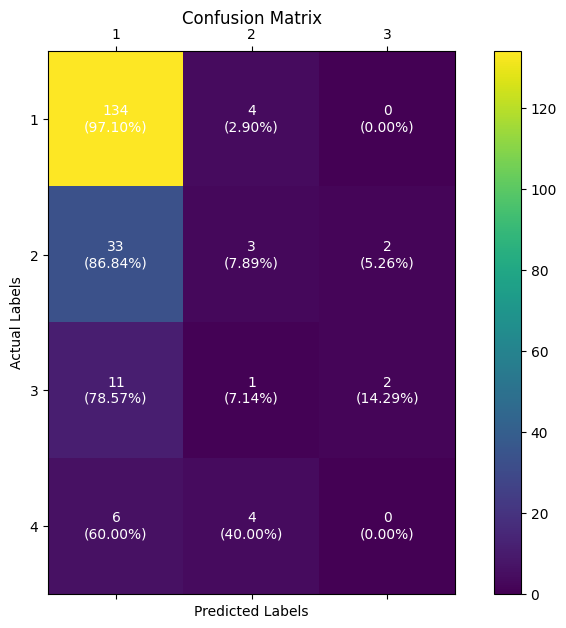

In [18]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

# make confusion matrix
y_pred = model.predict(X_test)
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
confusion_matrix_percentage = confusion_matrix.div(confusion_matrix.sum(axis=1), axis=0) * 100
print(confusion_matrix)

plt.figure(figsize=(10, 7))
plt.matshow(confusion_matrix, cmap='viridis', fignum=1)

plt.colorbar()

plt.title('Confusion Matrix', pad=20)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.xticks(ticks=range(len(confusion_matrix.columns)), labels=confusion_matrix.columns)
plt.yticks(ticks=range(len(confusion_matrix.index)), labels=confusion_matrix.index)

for (i, j), value in np.ndenumerate(confusion_matrix):
    percentage = confusion_matrix_percentage.iloc[i, j]
    plt.text(j, i, f'{value}\n({percentage:.2f}%)', ha='center', va='center', color='white')

plt.show()

## Extracting the feature importance

In [19]:
feature_importance = model.feature_importances_
feature_importance

array([0.05951876, 0.0545288 , 0.0663758 , 0.06661645, 0.08364326,
       0.07019229, 0.06951122, 0.07176829, 0.0508359 , 0.0779793 ,
       0.05534967, 0.07260331, 0.09705778, 0.04555305, 0.05846611])

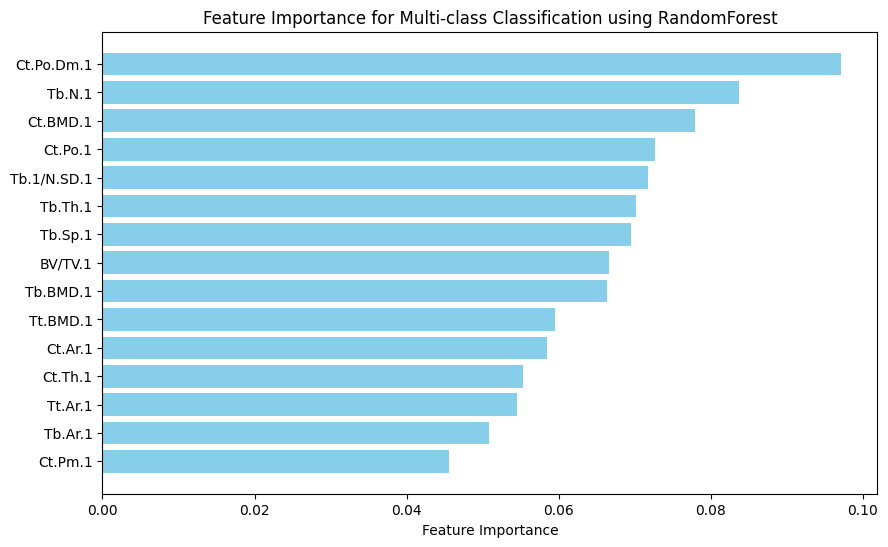

In [20]:
import matplotlib.pyplot as plt

if BONE == 'tibia':
    feature_names = tibia_columns
else:
    feature_names = radius_columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Multi-class Classification using RandomForest')
plt.gca().invert_yaxis()
plt.show()
